# 11 - Analysis of the rail network only

The national GTFS file is dominated by buses: tens of thousands of routes and millions of stop-time records.
Heavy rail (`route_type = 2`) is a tiny sub-network inside it - about 67 active stations and 99 undirected
service edges - and that small size is an opportunity. Everything that had to be sampled or approximated on the
bus network (betweenness in particular) can be computed **exactly** here, and every single-station closure can be
simulated by brute force. This notebook extracts the rail layer from the raw file, builds the graph, measures
centrality, finds the articulation points and bridges, and compares targeted station closures against the same
number of random failures.

**Research question.** Which rail stations are structurally critical, and how much more severe is a deliberate
attack on the rail network than an equal number of random failures?

**Input**
- `israel-public-transportation/routes.txt`, `trips.txt`, `stops.txt`, `calendar.txt` (tracked in git)
- `israel-public-transportation/stop_times.txt` (816 MB, **not** tracked in git - downloaded on demand)

**Output** (all under `outputs/nb/11_rail_network_analysis/`)
- `tables/mode_inventory.csv` - number of routes/trips per transport mode in the GTFS, showing how small rail is
- `tables/rail_station_metrics.csv` - per station: degree, PageRank, exact betweenness, harmonic, community, articulation flag
- `tables/top_betweenness_stations.csv`, `tables/top_weighted_degree_stations.csv`
- `tables/rail_articulation_points.csv`, `tables/rail_bridges.csv`
- `tables/single_station_damage.csv` - the fragmentation caused by closing each station on its own
- `tables/rail_resilience_curves.csv` - targeted versus random removal curves
- `tables/rail_service_edges.csv` - directed edge list with trip-record weights
- `summary.json` - build counts and statistics for the whole network
- `figures/` - network map, top-betweenness bars, single-station damage bars, resilience curves, centrality-correlation heatmap

**Prior steps required:** none. This notebook reads the raw GTFS file directly and is self-contained.

---

## Read this before interpreting any number below

**1. This is a graph of scheduled service, not a map of physical rail infrastructure.** An edge exists between two
stations whenever some scheduled train stops at one and then at the other. Express services skip stations, so they
create edges between stations that are *not* physically adjacent. The graph therefore encodes *how the service is
operated*, which is exactly what you want when asking "who still gets a train if this station closes", but it should
not be read as an infrastructure diagram. A bridge in this graph is a bridge in the timetable, not necessarily a
single physical rail line.

**2. Edge weights count GTFS trip records, not service days.** A weight of 219 means 219 trip records in the file
cross that edge. GTFS splits a timetable into service patterns, so a variant that runs only on Sundays contributes
exactly the same weight as a daily variant with the same number of trips. The weights are a proxy for the *richness
of the service patterns*, not for trains per week. All the structural conclusions below (articulation points,
bridges, fragmentation) use the **unweighted** topology and are unaffected by this; only weighted degree and
PageRank inherit this caveat.

## Setting up the working environment

Locates the repository (and clones it on Google Colab), installs only the packages that are actually missing, and
creates the main output directory. Rerunning this cell is safe.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Repo root: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר


## Libraries and analysis constants

Everything that controls compute cost or reproducibility is collected in one place. The rail graph has only 67
nodes, so there's no need to sample any centrality measure - the expensive parameter here is the Monte Carlo
experiment for the random failures, which runs `RANDOM_TRIALS` independent shuffles and re-evaluates connectivity
after each removal step (500 trials times 16 steps takes a few seconds). `SEED` fixes both the Louvain community
detection and the random failure orders, so the notebook reproduces exactly.

In [2]:
_ensure("networkx", "pandas", "numpy", "matplotlib", "seaborn")

import csv
import json
import random
import time
from collections import Counter, defaultdict

import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# --- Analysis constants -------------------------------------------------
RAIL_ROUTE_TYPE = "2"   # GTFS route_type 2 = heavy rail (Israel Railways)
SEED = 42               # fixes Louvain communities and random-failure orderings
RANDOM_TRIALS = 500     # Monte-Carlo repetitions for the random-failure baseline
MAX_REMOVALS = 15       # how far the resilience curves run along the x-axis

# --- Stage output folders ----------------------------------------------
STAGE = OUT / "11_rail_network_analysis"
TABLES = STAGE / "tables"
FIGURES = STAGE / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print("networkx", nx.__version__, "| pandas", pd.__version__)
print("Stage folder:", STAGE)

networkx 3.4.2 | pandas 2.3.3
Stage folder: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\11_rail_network_analysis


## Downloading the raw stop-times file

`stop_times.txt` weighs 816 MB - too large to keep in git - so it's stored separately and pulled on demand. Every
stop event in the country is in this single file (about 15.7 million rows); the rail subset we need is about 14,600
of them.

In [3]:
# stop_times.txt is 816MB and is not tracked in git - fetch it on demand.
_ensure("gdown")
import gdown
STOP_TIMES = DATA / "stop_times.txt"
if not STOP_TIMES.exists():
    gdown.download(id="1V_yPAWXV6mGTFGrfiosah5LngcLZnviW",
                   output=str(STOP_TIMES), quiet=False)
print("stop_times.txt:", round(STOP_TIMES.stat().st_size / 1024**2, 1), "MB")

stop_times.txt: 778.3 MB


## Handling Hebrew text

All station names in the file are in Hebrew. Matplotlib draws characters in logical order and does not apply the
Unicode bidirectional algorithm, so without this fix every Hebrew label displays reversed. We patch `Text.set_text`
once, before drawing any figure, so we can pass raw Hebrew strings through the rest of the notebook and get correct
output.

In [4]:
# Stop names are Hebrew. Whether they render reversed depends on the matplotlib build:
# most builds do NOT apply the Unicode bidi algorithm (so Hebrew must be reordered with
# python-bidi), but libraqm/raqm builds (some Colab installs, newer wheels) apply bidi
# themselves. We detect what THIS matplotlib does and only reorder when it does not, so
# labels render correctly on every environment and are never double-reversed.
_ensure("python-bidi")
import re
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext
from bidi.algorithm import get_display

def _mpl_reorders_hebrew():
    """True if matplotlib already applies the bidi algorithm itself (so get_display must NOT be applied)."""
    try:
        from matplotlib.figure import Figure
        from matplotlib.backends.backend_agg import FigureCanvasAgg
        def _ink_cols(s):
            fig = Figure(figsize=(3, 1), dpi=100)
            FigureCanvasAgg(fig)
            ax = fig.add_axes([0, 0, 1, 1])
            ax.axis("off")
            ax.text(0.5, 0.5, s, fontsize=32, ha="center", va="center")
            fig.canvas.draw()
            prof = (np.asarray(fig.canvas.buffer_rgba())[:, :, :3].mean(2) < 128).sum(0).astype(float)
            nz = np.where(prof > 0)[0]
            return prof[nz.min():nz.max() + 1] if len(nz) else prof
        # Probe: Hebrew letters then digits. The digits are logically LAST, so in plain
        # logical order they render on the RIGHT; if matplotlib applies bidi they move LEFT.
        probe = _ink_cols("אבג12")
        tmpl = _ink_cols("12")
        n = len(tmpl)
        if n < 2 or len(probe) <= n:
            return False
        t = tmpl - tmpl.mean()
        best_c, best_off = -2.0, 0
        for off in range(len(probe) - n + 1):
            w = probe[off:off + n] - probe[off:off + n].mean()
            denom = ((w * w).sum() * (t * t).sum()) ** 0.5
            c = float((w * t).sum() / denom) if denom > 0 else 0.0
            if c > best_c:
                best_c, best_off = c, off
        return (best_off / (len(probe) - n)) < 0.5
    except Exception:
        return False

# Decide once, at import time, whether matplotlib already handles Hebrew.
_MPL_BIDI = _mpl_reorders_hebrew()

# Fail loudly only when we actually depend on python-bidi (matplotlib is NOT reordering).
# A broken or no-op build would make get_display a pass-through and render Hebrew reversed.
if not _MPL_BIDI and get_display("אבג") != "גבא":
    raise RuntimeError(
        "matplotlib does not reorder Hebrew and python-bidi is a no-op; Hebrew figure "
        "labels would render reversed. Reinstall a working build:\n"
        "    pip install -U --force-reinstall 'python-bidi>=0.6.7'"
    )

_HEBREW_RE = re.compile(r"[֐-׿]")

def fix_he(text):
    """Return display-ordered text. Left untouched for non-Hebrew, or when matplotlib already applies bidi."""
    if _MPL_BIDI or not isinstance(text, str) or not _HEBREW_RE.search(text):
        return text
    return get_display(text)

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    if getattr(mtext.Text, "_bidi_patched", False):
        return
    _orig = mtext.Text.set_text
    def set_text(self, s):
        if isinstance(s, str) and getattr(self, "_bidi_display", None) == s:
            return _orig(self, s)
        fixed = fix_he(s)
        if isinstance(fixed, str):
            self._bidi_display = fixed
        return _orig(self, fixed)
    mtext.Text.set_text = set_text
    mtext.Text._bidi_patched = True

install_hebrew()

# Because the patch is global, pass RAW Hebrew strings to matplotlib from here on -
# calling fix_he() manually as well would reverse the text twice.

## Loading the GTFS metadata and measuring the size of each transport mode

The four small GTFS tables are read as raw strings: GTFS identifiers are opaque codes, and if we let pandas guess
numeric types it would silently drop leading zeros and break the joins. The mode inventory then joins `trips` to
`routes`, so you can see how many route records and how many scheduled trips each transport mode contributes - this
is the evidence that rail is a marginal segment of the file by volume, and therefore cheap to analyze exhaustively.

In [5]:
def read_gtfs(path):
    """Read a GTFS table as strings. Fails loudly on a missing or placeholder file."""
    if not path.exists() or path.stat().st_size < 100:
        raise FileNotFoundError(
            f"Missing or unhydrated GTFS file: {path}. "
            "Check that the israel-public-transportation folder was cloned in full."
        )
    return pd.read_csv(path, dtype=str, encoding="utf-8-sig")

def route_type_label(route_type):
    """Human-readable name for the GTFS route_type codes used in this feed."""
    return {
        "0": "tram/light rail",
        "2": "rail",
        "3": "bus",
        "5": "cable tram",
        "8": "trolleybus/taxi-coded",
        "715": "demand/other bus",
    }.get(str(route_type), "other")

def mode_inventory(routes, trips):
    """Route records and scheduled trips per mode."""
    route_counts = routes.groupby("route_type").size().rename("route_records")
    trip_counts = (
        trips.merge(routes[["route_id", "route_type"]], on="route_id", how="left")
        .groupby("route_type")
        .size()
        .rename("scheduled_trips")
    )
    inventory = pd.concat([route_counts, trip_counts], axis=1).fillna(0).reset_index()
    inventory["route_type_label"] = inventory["route_type"].map(route_type_label)
    inventory["route_records"] = inventory["route_records"].astype(int)
    inventory["scheduled_trips"] = inventory["scheduled_trips"].astype(int)
    return inventory[
        ["route_type", "route_type_label", "route_records", "scheduled_trips"]
    ]

routes = read_gtfs(DATA / "routes.txt")
trips = read_gtfs(DATA / "trips.txt")
stops = read_gtfs(DATA / "stops.txt")
calendar = read_gtfs(DATA / "calendar.txt")

inventory = mode_inventory(routes, trips)
print(f"routes={len(routes):,}  trips={len(trips):,}  stops={len(stops):,}")
inventory

routes=7,792  trips=420,133  stops=34,932


,route_type,route_type_label,route_records,scheduled_trips
0,0,tram/light rail,8,2890
1,2,rail,962,1188
2,3,bus,6796,412544
3,5,cable tram,4,3006
4,715,demand/other bus,14,458
5,8,trolleybus/taxi-coded,8,47


## Isolating the rail layer

We keep the routes where `route_type` equals 2 and all the trips belonging to one of them. The resulting set of
`trip_id`s is the filter used when reading the huge stop-times file. We also read the service calendar for those
trips, so the report can state exactly which timetable window the conclusions refer to - GTFS files are snapshots,
and a result produced from a one-month window shouldn't be presented as a permanent property of the network.

In [6]:
rail_routes = routes[routes["route_type"] == RAIL_ROUTE_TYPE].copy()
rail_trips = trips[trips["route_id"].isin(rail_routes["route_id"])].copy()
if rail_routes.empty or rail_trips.empty:
    raise RuntimeError("The GTFS feed contains no route_type=2 rail service")

def service_date_range(rail_trips, calendar):
    """Earliest start and latest end date of the calendars used by rail trips."""
    relevant = calendar[calendar["service_id"].isin(rail_trips["service_id"])]
    if relevant.empty:
        return "", ""
    def iso_date(raw):
        raw = str(raw)
        return f"{raw[:4]}-{raw[4:6]}-{raw[6:8]}" if len(raw) == 8 else raw
    return iso_date(relevant["start_date"].min()), iso_date(relevant["end_date"].max())

start_date, end_date = service_date_range(rail_trips, calendar)
rail_trip_ids = set(rail_trips["trip_id"])

print(f"rail route records      : {len(rail_routes):,}")
print(f"unique route long names : {rail_routes['route_long_name'].nunique():,}")
print(f"scheduled rail trips    : {len(rail_trips):,}")
print(f"service window          : {start_date} .. {end_date}")

rail route records      : 962
unique route long names : 82
scheduled rail trips    : 1,188
service window          : 2026-04-19 .. 2026-05-19


## Streaming the rail rows out of `stop_times.txt`

The file holds about 15.7 million stop events and doesn't fit comfortably in memory as a DataFrame, so we read it
line by line with the standard `csv` module and keep only the rows where `trip_id` is a rail trip - a few thousand
rows survive. For each surviving trip we collect `(stop_sequence, stop_id)` pairs, and we also count how many times
each station is stopped at, a measure that's useful as a sanity check against degree later on.

**Cost:** this is the slowest cell in the notebook - about 1 to 3 minutes depending on disk speed, since all 15.7
million rows have to be parsed even though almost all of them are thrown away. We map the header row once and use
`csv.reader` instead of `csv.DictReader`, which is significantly faster on a file this size and behaves identically.

In [7]:
def collect_rail_stop_times(stop_times_path, rail_trip_ids):
    """Stream the national stop-times file but retain only the small rail subset.

    Returns (sequences, stop_use_counts, total_rows_seen, rail_rows_kept).
    """
    sequences = defaultdict(list)
    stop_use_counts = Counter()
    all_rows = 0
    rail_rows = 0
    with stop_times_path.open(encoding="utf-8-sig", newline="") as handle:
        reader = csv.reader(handle)
        header = next(reader)
        required = {"trip_id", "stop_id", "stop_sequence"}
        if not required.issubset(set(header)):
            raise ValueError(f"stop_times.txt is missing fields: {sorted(required)}")
        i_trip = header.index("trip_id")
        i_stop = header.index("stop_id")
        i_seq = header.index("stop_sequence")
        for row in reader:
            all_rows += 1
            if row[i_trip] not in rail_trip_ids:
                continue
            rail_rows += 1
            try:
                sequence = int(float(row[i_seq]))
            except ValueError:
                continue  # unparsable sequence: the row cannot be ordered, so skip it
            stop_id = row[i_stop]
            sequences[row[i_trip]].append((sequence, stop_id))
            stop_use_counts[stop_id] += 1
    return sequences, stop_use_counts, all_rows, rail_rows

_t0 = time.perf_counter()
sequences, stop_calls, source_rows, rail_rows = collect_rail_stop_times(
    STOP_TIMES, rail_trip_ids
)
print(f"scanned {source_rows:,} stop-time rows in {time.perf_counter() - _t0:.1f}s")
print(f"kept {rail_rows:,} rail rows across {len(sequences):,} trips")
print(f"rail share of the feed: {100 * rail_rows / max(source_rows, 1):.4f}%")

scanned 15,711,624 stop-time rows in 6.5s
kept 14,601 rail rows across 1,188 trips
rail share of the feed: 0.0929%


## Building the rail graph

The graph definition deliberately matches the main bus network analysis, so the two are comparable:

- **node** = an active Israel Railways station
- **directed edge** `u -> v` = some scheduled train stops at `u` and immediately afterward at `v`
- **weight** = the number of scheduled trip records that use the edge between the two stations

Each trip's station list is sorted by `stop_sequence` (GTFS doesn't guarantee the row order in the file), and
consecutive pairs become edges; self-loops from duplicate rows are removed. The undirected view sums the weights of
both directions, and it's the one all the structural analysis is based on, since a closed station blocks travel in
both directions.

Keep in mind the two caveats at the top of the notebook: successive *in the timetable* isn't the same as adjacent
*on the track*, and the weight counts trip records, not service days.

In [8]:
def build_graphs(sequences):
    """Turn per-trip stop sequences into a weighted directed graph and its undirected view."""
    edge_counts = Counter()
    nodes = set()
    for trip_sequence in sequences.values():
        ordered = [stop for _, stop in sorted(trip_sequence)]
        nodes.update(ordered)
        for source, target in zip(ordered, ordered[1:]):
            if source != target:  # ignore duplicated rows for the same station
                edge_counts[(source, target)] += 1

    directed = nx.DiGraph()
    directed.add_nodes_from(nodes)
    for (source, target), weight in edge_counts.items():
        directed.add_edge(source, target, weight=int(weight))

    undirected = nx.Graph()
    undirected.add_nodes_from(nodes)
    for source, target, data in directed.edges(data=True):
        weight = int(data["weight"])
        if undirected.has_edge(source, target):
            undirected[source][target]["weight"] += weight
        else:
            undirected.add_edge(source, target, weight=weight)
    return directed, undirected

directed, undirected = build_graphs(sequences)
print(f"stations               : {undirected.number_of_nodes()}")
print(f"directed service edges : {directed.number_of_edges()}")
print(f"undirected service edges: {undirected.number_of_edges()}")
print(f"connected components   : {nx.number_connected_components(undirected)}")

stations               : 67
directed service edges : 197
undirected service edges: 99
connected components   : 1


## Attaching station names and coordinates

So far the graph only knows opaque `stop_id` values. Here we attach coordinates and Hebrew names from `stops.txt` to
the nodes, so the maps and tables are readable.

The original script assumed that every node in the graph had a matching row in `stops.txt`, and would have crashed
later with an unhelpful pandas `KeyError` if it didn't. We check this assumption explicitly and raise an actionable
error message, and we also verify that the coordinates parsed as numbers - a latitude that silently became NaN would
have produced a broken map with no error message at all.

In [9]:
def attach_stop_metadata(directed, undirected, stops):
    """Copy name/code/lat/lon onto the nodes; return the active-stop table."""
    active = stops[stops["stop_id"].isin(undirected.nodes)].copy()

    missing = set(undirected.nodes) - set(active["stop_id"])
    if missing:
        raise KeyError(
            f"{len(missing)} rail stop_id(s) appear in stop_times.txt but not in stops.txt "
            f"(e.g. {sorted(missing)[:5]}). The GTFS feed files are out of sync - "
            "re-download israel-public-transportation/ and stop_times.txt from the same snapshot."
        )

    active["stop_lat"] = pd.to_numeric(active["stop_lat"], errors="coerce")
    active["stop_lon"] = pd.to_numeric(active["stop_lon"], errors="coerce")
    bad_coords = active[active[["stop_lat", "stop_lon"]].isna().any(axis=1)]
    if not bad_coords.empty:
        raise ValueError(
            f"{len(bad_coords)} rail stops have unparsable coordinates: "
            f"{bad_coords['stop_id'].tolist()[:5]}"
        )

    active = active.set_index("stop_id", drop=False)
    for stop_id in undirected.nodes:
        row = active.loc[stop_id]
        attributes = {
            "stop_name": row.get("stop_name", ""),
            "stop_code": row.get("stop_code", ""),
            "lat": float(row["stop_lat"]),
            "lon": float(row["stop_lon"]),
        }
        directed.nodes[stop_id].update(attributes)
        undirected.nodes[stop_id].update(attributes)
    return active.reset_index(drop=True)

active_stops = attach_stop_metadata(directed, undirected, stops)
print(f"metadata attached for {len(active_stops)} active rail stations")
active_stops[["stop_id", "stop_code", "stop_name", "stop_lat", "stop_lon"]].head()

metadata attached for 67 active rail stations


,stop_id,stop_code,stop_name,stop_lat,stop_lon
0,37290,17106,שדרות,31.515877,34.586059
1,37292,17104,תל אביב ההגנה,32.053978,34.784839
2,37294,17102,רשל''צ משה דיין,31.987987,34.757392
3,37296,17100,הוד השרון,32.170213,34.901609
4,37298,17098,ראשונים,31.948927,34.802622


## Exact centrality, articulation points, bridges, and communities

Here the small size of the rail network pays off. On the bus graph we had to estimate betweenness from a sample of
source nodes; with 67 stations we run Brandes' algorithm on **all** of them, so these betweenness values are exact
and not an approximation. The measures and the reasoning behind each:

- **degree / weighted degree** - how many neighbors a station has, and how much scheduled service passes through it.
  Weighted degree carries the trip-record caveat.
- **PageRank** (on the directed, weighted graph) - importance under a passenger's random walk.
- **betweenness** (unweighted, undirected) - the fraction of shortest paths between stations that pass through a
  given station. Unweighted on purpose: we want *structural* transit load, measured in hops, not the version biased
  by service frequency.
- **harmonic centrality**, normalized by `n - 1` - a closeness measure that stays finite even if the graph isn't
  connected.
- **articulation points** - stations whose removal disconnects the graph. These, not the centrality scores, are the
  direct answer to the resilience question.
- **bridges** - edges whose removal disconnects the graph.
- **Louvain communities** (weighted, seeded) - the service clusters the timetable induces.

Each of these is exact, and the whole cell runs in well under a second.

In [10]:
def compute_metrics(directed, undirected, stop_use_counts, active_stops, seed):
    """Per-station metric table plus the bridge table. All values are exact."""
    degree = dict(undirected.degree())
    weighted_degree = dict(undirected.degree(weight="weight"))
    pagerank = nx.pagerank(directed, weight="weight")
    # normalized=True, weight=None -> exact, hop-based betweenness over all 67 sources
    betweenness = nx.betweenness_centrality(undirected, normalized=True, weight=None)
    harmonic_raw = nx.harmonic_centrality(undirected)
    harmonic_denominator = max(1, undirected.number_of_nodes() - 1)
    harmonic = {n: v / harmonic_denominator for n, v in harmonic_raw.items()}
    articulation = set(nx.articulation_points(undirected))
    bridges = set(nx.bridges(undirected))

    communities = nx.community.louvain_communities(undirected, weight="weight", seed=seed)
    community_by_node = {}
    for community_id, members in enumerate(sorted(communities, key=len, reverse=True), start=1):
        for node in members:
            community_by_node[node] = community_id

    metadata = active_stops.set_index("stop_id")
    rows = []
    for node in undirected.nodes:
        row = metadata.loc[node]
        rows.append(
            {
                "stop_id": node,
                "stop_code": row.get("stop_code", ""),
                "stop_name": row.get("stop_name", ""),
                "stop_lat": float(row["stop_lat"]),
                "stop_lon": float(row["stop_lon"]),
                "scheduled_stop_calls": int(stop_use_counts[node]),
                "degree": int(degree[node]),
                "weighted_degree": int(weighted_degree[node]),
                "in_degree": int(directed.in_degree(node)),
                "out_degree": int(directed.out_degree(node)),
                "pagerank": float(pagerank[node]),
                "betweenness": float(betweenness[node]),
                "harmonic": float(harmonic[node]),
                "is_articulation_point": node in articulation,
                "community_id": int(community_by_node[node]),
            }
        )
    metrics = pd.DataFrame(rows)

    names = metrics.set_index("stop_id")["stop_name"].to_dict()
    bridge_rows = [
        {
            "from_stop_id": source,
            "from_stop_name": names[source],
            "to_stop_id": target,
            "to_stop_name": names[target],
            "scheduled_trip_segments": int(undirected[source][target]["weight"]),
        }
        for source, target in sorted(bridges)
    ]
    return metrics, pd.DataFrame(bridge_rows)

_t0 = time.perf_counter()
metrics, bridges = compute_metrics(directed, undirected, stop_calls, active_stops, SEED)
print(f"exact metrics for {len(metrics)} stations in {time.perf_counter() - _t0:.2f}s")
metrics.nlargest(10, "betweenness")[
    ["stop_name", "degree", "weighted_degree", "betweenness", "pagerank",
     "is_articulation_point"]
]

exact metrics for 67 stations in 0.01s


,stop_name,degree,weighted_degree,betweenness,pagerank,is_articulation_point
25,תל אביב ההגנה,8,1493,0.537840,0.039443,True
37,הרצליה,8,846,0.514608,0.022429,False
42,תל אביב מרכז,4,1543,0.508625,0.031372,True
47,לוד,8,557,0.398213,0.029739,True
46,חוף הכרמל,6,688,0.364180,0.020354,True
1,חיפה מרכז,7,815,0.339860,0.025639,True
45,נתב''ג,4,617,0.310023,0.018163,True
22,השלום,2,1502,0.221911,0.032019,False
7,קרית גת,4,140,0.184149,0.012144,False
6,קרית מוצקין,6,624,0.158974,0.023180,True


## Whole-network statistics

A concise profile of the graph: whether it's connected, how sparse it is, how many hops separate an average pair of
stations, and how many articulation points and bridges it contains. The average shortest-path length and the
diameter are computed on the largest connected component, since those quantities aren't defined across separate
components.

In [11]:
def network_summary(graph, directed, metrics, communities):
    components = list(nx.connected_components(graph))
    largest = graph.subgraph(max(components, key=len)).copy()
    return {
        "active_stations": graph.number_of_nodes(),
        "directed_service_edges": directed.number_of_edges(),
        "undirected_service_edges": graph.number_of_edges(),
        "connected_components": len(components),
        "largest_component_stations": largest.number_of_nodes(),
        "largest_component_share": largest.number_of_nodes() / graph.number_of_nodes(),
        "average_degree": sum(dict(graph.degree()).values()) / graph.number_of_nodes(),
        "density": nx.density(graph),
        "average_clustering": nx.average_clustering(graph),
        "average_shortest_path_hops_lcc": nx.average_shortest_path_length(largest),
        "diameter_hops_lcc": nx.diameter(largest),
        "articulation_points": int(metrics["is_articulation_point"].sum()),
        "bridges": int(sum(1 for _ in nx.bridges(graph))),
        "louvain_communities": communities,
    }

n_communities = metrics["community_id"].nunique()
summary = network_summary(undirected, directed, metrics, n_communities)
for key, value in summary.items():
    print(f"{key:34s} {value:.4f}" if isinstance(value, float) else f"{key:34s} {value}")

active_stations                    67
directed_service_edges             197
undirected_service_edges           99
connected_components               1
largest_component_stations         67
largest_component_share            1.0000
average_degree                     2.9552
density                            0.0448
average_clustering                 0.3653
average_shortest_path_hops_lcc     5.6260
diameter_hops_lcc                  13
articulation_points                14
bridges                            11
louvain_communities                8


## The cut nodes and cut edges

Articulation points and bridges are the sharpest structural result in this notebook: they're yes/no facts about the
graph, not scores that need some threshold. An articulation point is a station whose closure splits the timetable
graph into parts that can't reach each other; a bridge is an edge with the same property.

Notice that some of the articulation points have *low* betweenness. A quiet terminal station that's the only way to
a particular branch is structurally critical even though very few shortest paths cross it - and that's exactly why
centrality alone isn't a sufficient criterion for criticality.

In [12]:
articulation_points = (
    metrics[metrics["is_articulation_point"]]
    .sort_values("betweenness", ascending=False)
    [["stop_id", "stop_code", "stop_name", "degree", "weighted_degree",
      "betweenness", "community_id"]]
    .reset_index(drop=True)
)
print(f"articulation points: {len(articulation_points)}")
print(f"bridges            : {len(bridges)}")
display(articulation_points)
display(bridges.sort_values("scheduled_trip_segments", ascending=False).reset_index(drop=True))

articulation points: 14
bridges            : 11


,stop_id,stop_code,stop_name,degree,weighted_degree,betweenness,community_id
0,37292,17104,תל אביב ההגנה,8,1493,0.537840,5
1,37358,17038,תל אביב מרכז,4,1543,0.508625,5
2,37338,17058,לוד,8,557,0.398213,1
3,37376,17020,חוף הכרמל,6,688,0.364180,2
4,37380,17016,חיפה מרכז,7,815,0.339860,2
5,37306,17090,נתב''ג,4,617,0.310023,5
6,41293,17117,קרית מוצקין,6,624,0.158974,3
7,37314,17082,באר שבע צפון,5,454,0.113287,6
8,40581,17113,כפר ברוך,4,212,0.059674,2
9,37336,17060,רמלה,3,204,0.056177,1


,from_stop_id,from_stop_name,to_stop_id,to_stop_name,scheduled_trip_segments
0,37394,מודיעין מרכז,37396,פאתי מודיעין,233
1,37312,באר שבע מרכז,37314,באר שבע צפון,219
2,37382,נהריה,37384,עכו,187
3,41293,קרית מוצקין,37384,עכו,187
4,41292,כרמיאל,41291,אחיהוד,121
5,41293,קרית מוצקין,41291,אחיהוד,121
6,40582,עפולה,40581,כפר ברוך,106
7,40583,בית שאן,40582,עפולה,106
8,37298,ראשונים,37338,לוד,59
9,37322,בית שמש,37336,רמלה,50


## How much damage does closing one station cause?

Instead of trusting any single centrality score, we simply try each station: remove it, examine what's left, and
record how many of the remaining stations fall outside the largest surviving connected component. With 67 nodes this
brute-force sweep is instant, and it's the ground truth the centrality rankings are trying to approximate.

We report two rates, and they answer different questions:
- `largest_component_share_of_remaining` - of the stations still open, what fraction can still reach each other.
- `serviceable_share_of_original` - the same count as a share of the original 67 stations, that is, how much of the
  network is still serviceable, accounting also for the loss of the closed station itself.

In [13]:
def graph_state(graph, removed):
    """Connectivity of the graph after deleting the given stations."""
    remaining = set(graph.nodes).difference(removed)
    original_nodes = graph.number_of_nodes()
    if not remaining:
        return {
            "remaining_stations": 0,
            "components": 0,
            "largest_component_nodes": 0,
            "largest_component_share_of_remaining": 0.0,
            "serviceable_share_of_original": 0.0,
        }
    subgraph = graph.subgraph(remaining)
    component_sizes = [len(c) for c in nx.connected_components(subgraph)]
    largest = max(component_sizes)
    return {
        "remaining_stations": len(remaining),
        "components": len(component_sizes),
        "largest_component_nodes": largest,
        "largest_component_share_of_remaining": largest / len(remaining),
        "serviceable_share_of_original": largest / original_nodes,
    }

def single_station_damage(graph, metrics):
    """Exhaustively close each station in turn and measure the fragmentation."""
    names = metrics.set_index("stop_id")["stop_name"].to_dict()
    rows = []
    for node in graph.nodes:
        state = graph_state(graph, [node])
        rows.append(
            {
                "stop_id": node,
                "stop_name": names[node],
                **state,
                "stations_outside_largest_component": int(
                    state["remaining_stations"] - state["largest_component_nodes"]
                ),
            }
        )
    return pd.DataFrame(rows).sort_values(
        ["stations_outside_largest_component", "components", "stop_name"],
        ascending=[False, False, True],
    )

damage = single_station_damage(undirected, metrics)
worst = damage.iloc[0]
print(
    f"Worst single closure: {worst['stop_name']} -> "
    f"{worst['components']} components, only "
    f"{100 * worst['serviceable_share_of_original']:.1f}% of stations still connected"
)
damage.head(12)[
    ["stop_name", "components", "largest_component_nodes",
     "stations_outside_largest_component", "serviceable_share_of_original"]
]

Worst single closure: תל אביב מרכז -> 2 components, only 49.3% of stations still connected


,stop_name,components,largest_component_nodes,stations_outside_largest_component,serviceable_share_of_original
42,תל אביב מרכז,2,33,33,0.492537
25,תל אביב ההגנה,2,39,27,0.582090
46,חוף הכרמל,2,51,15,0.761194
1,חיפה מרכז,3,53,13,0.791045
6,קרית מוצקין,3,62,4,0.925373
45,נתב''ג,2,63,3,0.940299
66,באר שבע צפון,3,64,2,0.955224
61,כפר ברוך,2,64,2,0.955224
52,אחיהוד,2,65,1,0.970149
47,לוד,2,65,1,0.970149


## Targeted closures versus random failures

The classic robustness experiment. We remove stations one by one in five different targeted orders (highest degree,
weighted degree, PageRank, betweenness, and an "articulation first" order that prioritizes cut nodes and then the
observed damage from a single-station closure) and track the size of the largest connected component. As a baseline
we repeat the same removals in `RANDOM_TRIALS` random orders and average the result.

The rankings are static: they're computed once on the full graph and then followed, which models an attacker
planning from a published timetable rather than one recomputing centrality after each closure. Recomputing would
necessarily be more damaging, so the targeted curves below are a conservative lower bound on the worst case.

**Cost:** `RANDOM_TRIALS x (MAX_REMOVALS + 1)` connectivity evaluations, a few seconds at the default values of 500
times 16.

In [14]:
def resilience_curves(graph, metrics, damage, max_removals, random_trials, seed):
    damage_rank = damage.set_index("stop_id")["stations_outside_largest_component"]
    ranked = metrics.copy()
    ranked["single_station_damage"] = ranked["stop_id"].map(damage_rank)
    rankings = {
        "degree": ranked.sort_values(
            ["degree", "weighted_degree"], ascending=False
        )["stop_id"].tolist(),
        "weighted_degree": ranked.sort_values("weighted_degree", ascending=False)[
            "stop_id"
        ].tolist(),
        "pagerank": ranked.sort_values("pagerank", ascending=False)["stop_id"].tolist(),
        "betweenness": ranked.sort_values("betweenness", ascending=False)[
            "stop_id"
        ].tolist(),
        "articulation_priority": ranked.sort_values(
            ["is_articulation_point", "single_station_damage", "degree"],
            ascending=False,
        )["stop_id"].tolist(),
    }
    max_removals = min(max_removals, graph.number_of_nodes() - 1)

    rows = []
    for strategy, ranking in rankings.items():
        for removed_count in range(max_removals + 1):
            rows.append(
                {
                    "strategy": strategy,
                    "removed_stations": removed_count,
                    **graph_state(graph, ranking[:removed_count]),
                }
            )

    rng = random.Random(seed)  # seeded so the baseline is reproducible
    nodes = list(graph.nodes)
    random_states = defaultdict(list)
    for _ in range(random_trials):
        ordering = rng.sample(nodes, len(nodes))
        for removed_count in range(max_removals + 1):
            random_states[removed_count].append(graph_state(graph, ordering[:removed_count]))
    for removed_count, states in random_states.items():
        row = {"strategy": "random_mean", "removed_stations": removed_count}
        for field in states[0]:
            row[field] = float(np.mean([float(state[field]) for state in states]))
        rows.append(row)
    return pd.DataFrame(rows)

_t0 = time.perf_counter()
resilience = resilience_curves(
    undirected, metrics, damage, MAX_REMOVALS, RANDOM_TRIALS, SEED
)
print(f"resilience curves computed in {time.perf_counter() - _t0:.1f}s")
resilience.pivot(
    index="removed_stations", columns="strategy", values="serviceable_share_of_original"
).round(3)

resilience curves computed in 0.9s


strategy,articulation_priority,betweenness,degree,pagerank,random_mean,weighted_degree
removed_stations,,,,,,
0,1.000,1.000,1.000,1.000,1.000,1.000
1,0.493,0.582,0.582,0.582,0.963,0.493
2,0.493,0.567,0.567,0.567,0.925,0.493
3,0.403,0.478,0.567,0.493,0.885,0.493
4,0.403,0.478,0.358,0.478,0.849,0.478
5,0.403,0.343,0.343,0.478,0.805,0.403
6,0.403,0.343,0.343,0.478,0.767,0.403
7,0.358,0.343,0.343,0.269,0.725,0.403
8,0.358,0.343,0.224,0.269,0.692,0.403


## One station versus one coin flip

The clearest number in this notebook: what happens after exactly one closure, when it's chosen by an adversary
versus chosen at random.

In [15]:
worst_row = damage.iloc[0]
random_one = resilience[
    (resilience["strategy"] == "random_mean") & (resilience["removed_stations"] == 1)
].iloc[0]

targeted_pct = 100 * float(worst_row["serviceable_share_of_original"])
random_pct = 100 * float(random_one["serviceable_share_of_original"])
print(f"Closing the single worst station ({worst_row['stop_name']}):")
print(f"  largest connected component = {targeted_pct:.1f}% of the original network")
print(f"  network splits into {int(worst_row['components'])} components")
print(f"Closing one station at random (mean of {RANDOM_TRIALS} trials):")
print(f"  largest connected component = {random_pct:.1f}% of the original network")
print(f"Gap: {random_pct - targeted_pct:.1f} percentage points from one informed choice.")

Closing the single worst station (תל אביב מרכז):
  largest connected component = 49.3% of the original network
  network splits into 2 components
Closing one station at random (mean of 500 trials):
  largest connected component = 96.3% of the original network
Gap: 47.1 percentage points from one informed choice.


## Figures

Five figures, each answering one question:

1. **Network map** - the graph drawn on real coordinates, node color = exact betweenness, node size = weighted
   degree. Here the spine-and-branches shape becomes clear.
2. **Top betweenness stations** - who carries the shortest-path load.
3. **Single-station damage** - which closures actually split the network (only stations that disconnect at least one
   other station are shown; most stations disconnect none).
4. **Resilience curves** - targeted strategies versus the random baseline.
5. **Centrality correlations** - Spearman correlation between the measures, to check whether they measure the same
   thing or genuinely different things.

The figures are written to the step's `figures/` directory and also displayed inside the notebook.

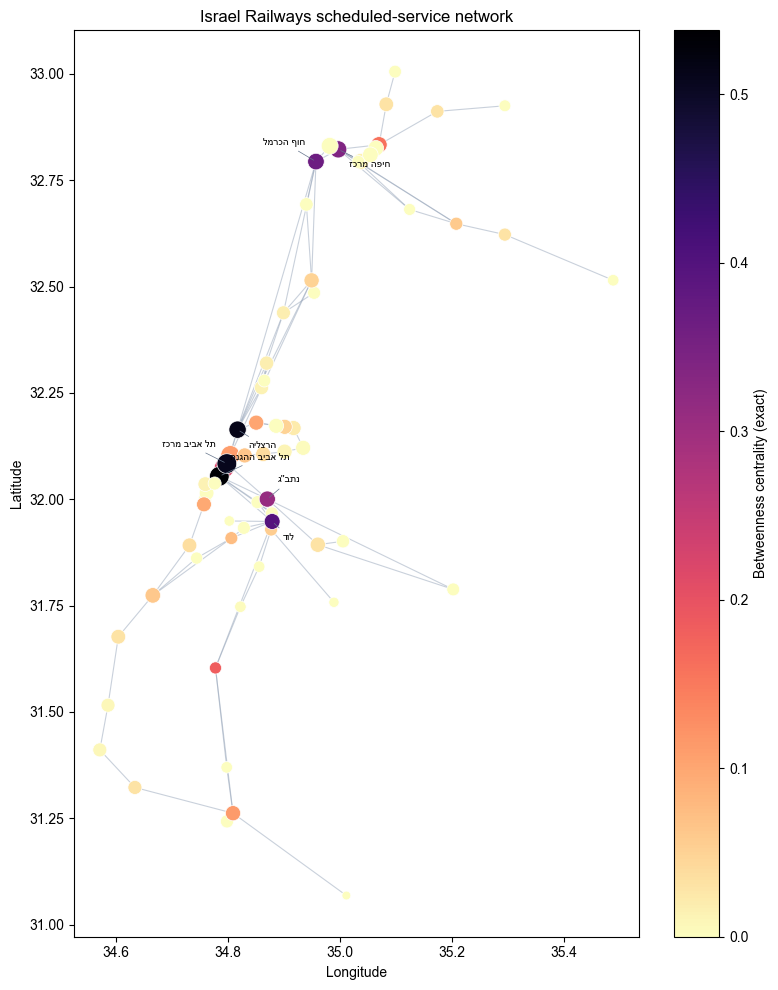

In [16]:
def plot_network_map(graph, metrics, path):
    indexed = metrics.set_index("stop_id")
    positions = {
        node: (float(indexed.loc[node, "stop_lon"]), float(indexed.loc[node, "stop_lat"]))
        for node in graph.nodes
    }
    segments = [[positions[s], positions[t]] for s, t in graph.edges]
    fig, axis = plt.subplots(figsize=(8, 10))
    axis.add_collection(
        LineCollection(segments, colors="#94a3b8", linewidths=0.8, alpha=0.5)
    )
    node_list = list(graph.nodes)
    values = indexed.loc[node_list, "betweenness"].to_numpy(float)
    weights = indexed.loc[node_list, "weighted_degree"].to_numpy(float)
    sizes = 22 + 180 * np.sqrt(weights / max(weights.max(), 1))
    scatter = axis.scatter(
        [positions[n][0] for n in node_list],
        [positions[n][1] for n in node_list],
        c=values, s=sizes, cmap="magma_r",
        edgecolor="white", linewidth=0.5, zorder=3,
    )
    label_offsets = [(8, 12), (8, -13), (-8, 12), (8, -13), (-8, 12), (8, -13), (8, 12)]
    for node, offset in zip(indexed.nlargest(7, "betweenness").index, label_offsets):
        x_pos, y_pos = positions[node]
        axis.annotate(
            indexed.loc[node, "stop_name"],  # raw Hebrew: the bidi patch fixes it
            (x_pos, y_pos), xytext=offset, textcoords="offset points", fontsize=7,
            ha="left" if offset[0] > 0 else "right",
            arrowprops={"arrowstyle": "-", "color": "#64748b", "lw": 0.5},
        )
    fig.colorbar(scatter, ax=axis, label="Betweenness centrality (exact)")
    axis.set_title("Israel Railways scheduled-service network")
    axis.set_xlabel("Longitude")
    axis.set_ylabel("Latitude")
    axis.autoscale()
    fig.tight_layout()
    fig.savefig(path, dpi=220)
    plt.show()

plot_network_map(undirected, metrics, FIGURES / "rail_network_map.png")

### Betweenness ranking and single-station damage

The first bar chart ranks stations by exact betweenness; the second shows the damage result obtained by brute force.
The comparison between them is the point - the order is similar at the top of the list but not identical, and there
are stations with high betweenness that split nothing, because the network routes around them.

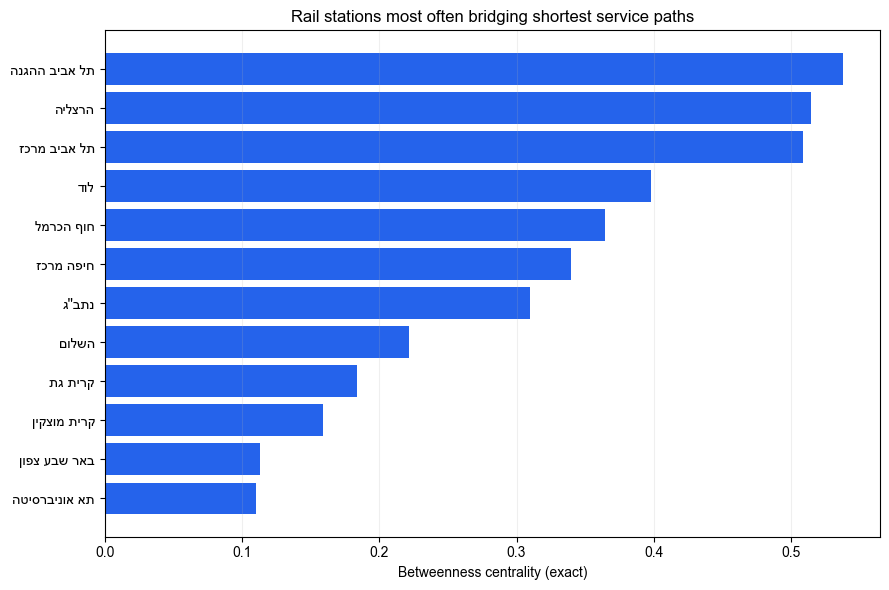

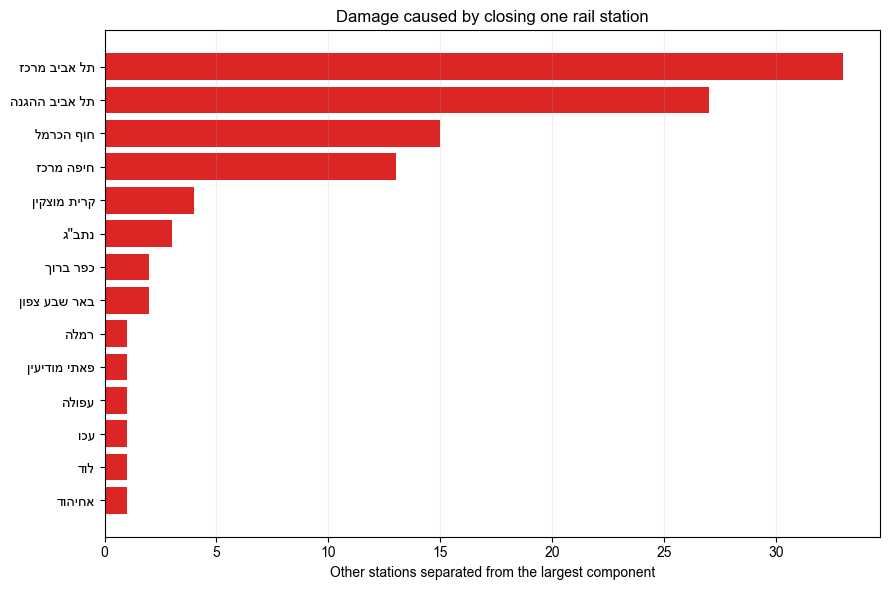

In [17]:
def plot_top_stations(metrics, path):
    top = metrics.nlargest(12, "betweenness").sort_values("betweenness")
    fig, axis = plt.subplots(figsize=(9, 6))
    axis.barh(list(top["stop_name"]), top["betweenness"], color="#2563eb")
    axis.set_xlabel("Betweenness centrality (exact)")
    axis.set_title("Rail stations most often bridging shortest service paths")
    axis.grid(axis="x", alpha=0.2)
    fig.tight_layout()
    fig.savefig(path, dpi=200)
    plt.show()

def plot_single_station_damage(damage, path):
    top = damage[damage["stations_outside_largest_component"] > 0].head(15)
    top = top.sort_values("stations_outside_largest_component")
    fig, axis = plt.subplots(figsize=(9, 6))
    axis.barh(
        list(top["stop_name"]),
        top["stations_outside_largest_component"],
        color="#dc2626",
    )
    axis.set_xlabel("Other stations separated from the largest component")
    axis.set_title("Damage caused by closing one rail station")
    axis.grid(axis="x", alpha=0.2)
    fig.tight_layout()
    fig.savefig(path, dpi=200)
    plt.show()

plot_top_stations(metrics, FIGURES / "top_betweenness_stations.png")
plot_single_station_damage(damage, FIGURES / "single_station_damage.png")

### Resilience curves and agreement between the measures

The resilience chart shows the largest connected component as a percentage of the original 67 stations after each
removal; the dashed gray line is the average of the random failures. The heatmap then checks how redundant our five
centrality measures are relative to each other: strongly correlated measures tell us the same story, and any weak
correlation signals a genuinely different notion of importance.

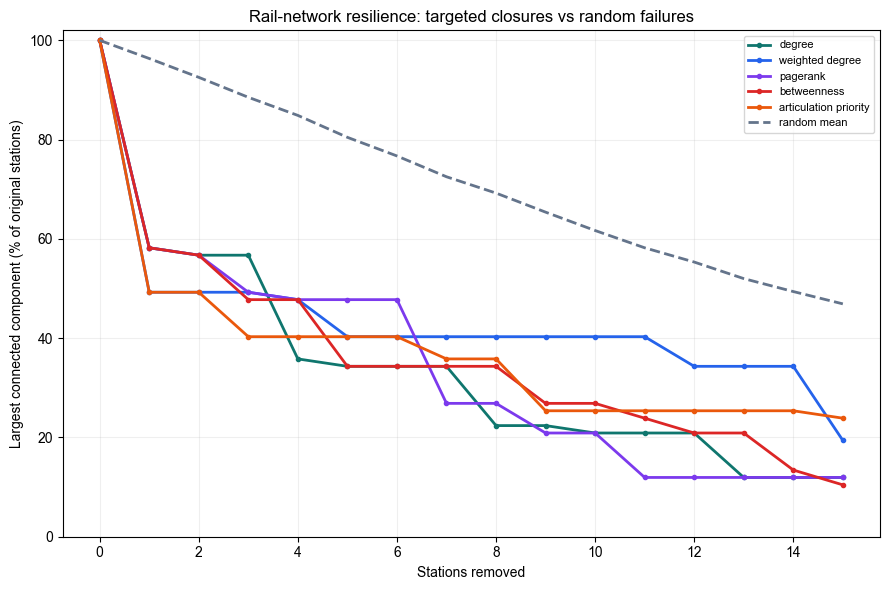

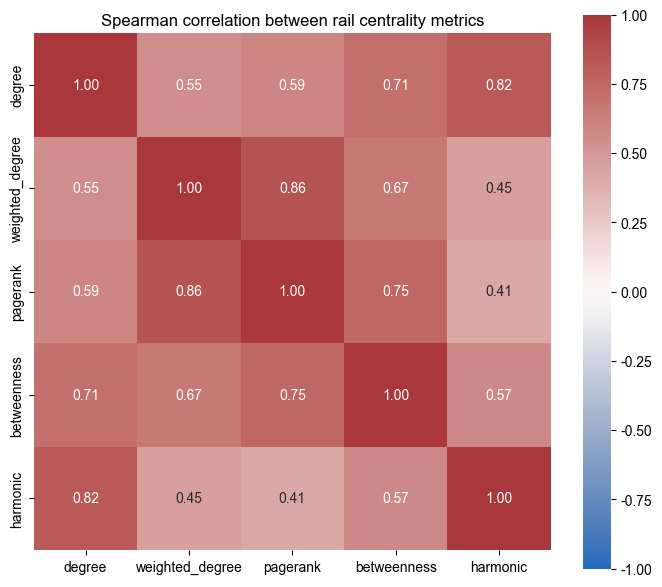

In [18]:
def plot_resilience(resilience, path):
    colors = {
        "degree": "#0f766e",
        "weighted_degree": "#2563eb",
        "pagerank": "#7c3aed",
        "betweenness": "#dc2626",
        "articulation_priority": "#ea580c",
        "random_mean": "#64748b",
    }
    fig, axis = plt.subplots(figsize=(9, 6))
    for strategy, group in resilience.groupby("strategy", sort=False):
        axis.plot(
            group["removed_stations"],
            100 * group["serviceable_share_of_original"],
            marker="o" if strategy != "random_mean" else None,
            markersize=3,
            linewidth=2,
            linestyle="--" if strategy == "random_mean" else "-",
            color=colors.get(strategy),
            label=strategy.replace("_", " "),
        )
    axis.set_xlabel("Stations removed")
    axis.set_ylabel("Largest connected component (% of original stations)")
    axis.set_title("Rail-network resilience: targeted closures vs random failures")
    axis.set_ylim(0, 102)
    axis.grid(alpha=0.2)
    axis.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(path, dpi=200)
    plt.show()

def plot_centrality_correlation(metrics, path):
    columns = ["degree", "weighted_degree", "pagerank", "betweenness", "harmonic"]
    correlation = metrics[columns].corr(method="spearman")
    fig, axis = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        correlation, annot=True, fmt=".2f", cmap="vlag",
        vmin=-1, vmax=1, square=True, ax=axis,
    )
    axis.set_title("Spearman correlation between rail centrality metrics")
    fig.tight_layout()
    fig.savefig(path, dpi=200)
    plt.show()

plot_resilience(resilience, FIGURES / "rail_resilience_curve.png")
plot_centrality_correlation(metrics, FIGURES / "centrality_correlation.png")

## Saving the results

Every table and the JSON summary are written to this notebook's step directory
(`outputs/nb/11_rail_network_analysis/`). The CSV files use `utf-8-sig` so Excel opens the Hebrew station names
correctly. The summary also records the build counts (rows scanned, rows kept, trips, service window), so you can
trace from the graph back to the snapshot of the file it was created from.

In [19]:
inventory.to_csv(TABLES / "mode_inventory.csv", index=False, encoding="utf-8-sig")
metrics.sort_values("betweenness", ascending=False).to_csv(
    TABLES / "rail_station_metrics.csv", index=False, encoding="utf-8-sig"
)
metrics.nlargest(15, "betweenness").to_csv(
    TABLES / "top_betweenness_stations.csv", index=False, encoding="utf-8-sig"
)
metrics.nlargest(15, "weighted_degree").to_csv(
    TABLES / "top_weighted_degree_stations.csv", index=False, encoding="utf-8-sig"
)
articulation_points.to_csv(
    TABLES / "rail_articulation_points.csv", index=False, encoding="utf-8-sig"
)
bridges.to_csv(TABLES / "rail_bridges.csv", index=False, encoding="utf-8-sig")
damage.to_csv(TABLES / "single_station_damage.csv", index=False, encoding="utf-8-sig")
resilience.to_csv(
    TABLES / "rail_resilience_curves.csv", index=False, encoding="utf-8-sig"
)

edge_rows = [
    {
        "from_stop_id": source,
        "to_stop_id": target,
        "scheduled_trip_segments": int(data["weight"]),
    }
    for source, target, data in directed.edges(data=True)
]
pd.DataFrame(edge_rows).sort_values("scheduled_trip_segments", ascending=False).to_csv(
    TABLES / "rail_service_edges.csv", index=False, encoding="utf-8-sig"
)

build_summary = {
    "source_stop_time_rows": int(source_rows),
    "rail_stop_time_rows": int(rail_rows),
    "rail_route_records": int(len(rail_routes)),
    "unique_route_descriptions": int(rail_routes["route_long_name"].nunique()),
    "scheduled_rail_trips": int(len(rail_trips)),
    "active_rail_stations": int(undirected.number_of_nodes()),
    "directed_service_edges": int(directed.number_of_edges()),
    "undirected_service_edges": int(undirected.number_of_edges()),
    "service_start_date": start_date,
    "service_end_date": end_date,
}
with (STAGE / "summary.json").open("w", encoding="utf-8") as handle:
    json.dump(
        {"build": build_summary, "network": summary},
        handle, ensure_ascii=False, indent=2,
    )

print("tables written to :", TABLES)
print("figures written to:", FIGURES)
print("summary written to:", STAGE / "summary.json")

tables written to : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\11_rail_network_analysis\tables
figures written to: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\11_rail_network_analysis\figures
summary written to: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\11_rail_network_analysis\summary.json


## Conclusions

**The rail network is a sparse spine, and that's what makes it fragile.** 67 active stations and 99 undirected
service edges give an average degree of about 3.0 and a density of about 0.045. The graph is fully connected, but
it's connected the way a tree with a few cycles is connected: an average pair of stations is about 5.6 hops apart
and the diameter is 13 hops.

**14 stations are articulation points and 11 edges are bridges.** That's about one station in five whose closure
disconnects part of the national rail service, and one edge in nine with the same property. This is a structural
fact about the timetable graph, not a score with a threshold, and it's the strongest resilience finding here.

**One well-informed closure is worth dozens of random ones.** Removing Tel Aviv Savidor Center alone splits the
network in two and leaves only about **49%** of the stations mutually connected. Removing one random station leaves
about **96%**. A gap of about 47 percentage points from a single choice is the signature of a network with very few
redundant paths - and it's true for the four Tel Aviv stations in general, since effectively all north-south rail
service is routed through the same corridor.

**Centrality is a good but imperfect proxy for criticality.** The centrality measures correlate strongly with each
other, and the top of the betweenness ranking does overlap with the top of the damage ranking. But some of the
articulation points have unimpressive betweenness - a quiet branch terminal is critical for the handful of stations
behind it and for no one else. The single-station brute-force sweep, which is only possible because the graph is
small, is the honest answer; on the bus network we can't afford it and have to rely on the proxies.

**Limitations - don't read more into these numbers than they support.**
1. *Scheduled service, not physical track.* Edges connect stations where trains stop in sequence. Express patterns
   therefore link stations that aren't physically adjacent, and a "bridge" here means a service edge that can't be
   substituted in the published timetable, not necessarily a single track segment. A real infrastructure study would
   need track data.
2. *The weights count trip records, not service days.* A service pattern that runs only on Sundays contributes the
   same weight per trip as a daily pattern, so weighted degree and PageRank measure the richness of service patterns
   rather than passengers or trains per week. All the structural results above use the unweighted graph and are
   immune to this.
3. *A single snapshot of the file.* Everything above describes the single timetable window printed in the service
   window cell above. Maintenance work, seasonal timetables, or a new line would change the topology.
4. *Topology only.* Connectivity is measured in stations, not passengers. Losing a two-station branch and losing a
   two-station segment in the Tel Aviv corridor are counted identically here; in reality they aren't. Weighting by
   ridership would sharpen every conclusion.
5. *Static attack order.* The targeted curves follow a ranking computed on the full graph. An adversary who
   recomputes after each closure would do more damage, so these curves are a lower bound on the worst case.